In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, kv
import scipy.stats as stats

# Вариант

*самая сложная часть*

In [1]:
ALPHABET = "АБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ"

In [3]:
first_letter_bobrov_index = ALPHABET.index("Б") + 1
first_letter_chunikhina_index = ALPHABET.index("Ч") + 1

In [4]:
mean_index = (first_letter_bobrov_index + first_letter_chunikhina_index) // 2

In [5]:
print(f"Вариант: {mean_index % 2 + 1}")

Вариант: 2


Итого Вариант 2

Соответствующие данные:
$$\operatorname{Exp}(\theta);\ \Gamma(k, \lambda);\ \lambda=k=1$$

# Пункт 1

## Функция правдеподобия

Так как мы предполагаем, что выполнено условие независимости выборки, то функция правдоподобия будет выглядеть следующим образом

$$
\operatorname{L}(\theta)=\prod^n_{i=1}p(x_i|\theta)
$$

Введем параметризацию и выразим $p(x)$ как:
$$
p(x)=\theta^{-1}e^{-x/\theta}
$$

Тогда функция правдоподобия будет выглядеть следующим образом:
$$
\operatorname{L}(\theta)=\prod^n_{i=1}\theta^{-1}e^{-x_i/\theta}=\theta^{-n}e^{\sum_{i=1}^n -x_i/\theta}=\theta^{-n} \exp \left(-\frac{\sum_{i=1}^n x_i}{\theta}\right)
$$

Для упрощения дальнейшего исчисления используем логарифм:
$$
\ell(\theta)=-n \ln \theta - \frac{\sum_{i=1}^n x_i}{\theta}
$$

## Нахождение максимума функции правдоподобия

Теперь найдем производную и соответствующий максимум данной функции – это и будет теоретическая оценка параметра $\theta$

$$
-\frac{n}{\theta}+\frac{\sum_{i=1}^n x_i}{\theta^2}=0
$$

Домножаем на $\theta$, переносим в одну часть и получаем теоретическую оценку параметра:
$$
\hat{\theta}_{\operatorname{MLE}}=\frac{\sum x_i}{n}
$$

## Нахождение теоретического математического ожидания

$$
\hat{\theta}=\frac{1}{n}\sum_{i=1}^n x_i \Rightarrow \mathbb{E}[\hat{\theta}]=\frac{1}{n}\sum \mathbb{E}[x_i]
$$

Для нашего распределения и того, как мы его ввели мат ожидание будет следующим: $\mathbb{E}[x]=\theta$

Следовательно,
$$
\mathbb{E}[\hat{\theta}]=\frac{1}{n} \cdot n \theta = \theta
$$

## Нахождение смещения

$$\operatorname{Bias}(\hat{\theta})=\mathbb{E}[\hat{\theta}]-\theta=\theta-\theta=0$$

Следовательно, наша оценка – несмещенная

## Нахождение дисперсии

$$
\operatorname{Var}(\hat{\theta})=\operatorname{Var} \left(\frac{1}{n}\sum_{i=1}^n x_i\right)
$$

По свойствам дисперсии выводим:
$$
\operatorname{Var} \left(\frac{1}{n}\sum_{i=1}^n x_i\right)=\frac{1}{n^2} \sum_{i=1}^n \operatorname{Var}(x_i)
$$

По теории у нас дисперсия равна $\theta^2$, следовательно:
$$
\operatorname{Var}(\hat{\theta})=\frac{\theta^2}{n}
$$

## MSE

MSE удобно находить через разложение через Var и Bias
$$
\operatorname{MSE}(\hat{\theta})=\operatorname{Var}(\hat{\theta}) + \operatorname{Bias}(\hat{\theta})^2=\frac{\theta^2}{n}
$$

# Пункт 2

## Априорное распределение

Найдем априорное распределение для нашей оценки

$$
p(\theta)=\frac{\lambda^{-k}\theta^{k - 1}e^{-\theta/\lambda}}{\Gamma(k)}=\frac{1^{-1}\theta^{1-1}e^{-\theta}}{\Gamma(1)}=e^{-\theta}
$$

## Апостериорная плотность

$$
p(\theta | X) = \frac{\theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)}{\int \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}
$$

Возьмем стандартную квадратическую функцию потерь. Так как для нее верно следующее:
$$
\hat{\theta_B}=\mathbb{E}[\theta|X]
$$

То можем вычислить теоретическую оценку параметра:
$$
\hat{\theta_B}=\frac{\int_0^\infty\theta \cdot \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}{\int \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)d\theta}
$$

## Подсчет оценок

Получившийся результат является обобщенным обратным гауссовским распределением (GIG). Информация о нем и в дальнейшем была найдена в этой [статье](https://en.wikipedia.org/wiki/Generalized_inverse_Gaussian_distribution).

Так как наша апостериорная плотность:
$$
p(\theta | X) \propto \theta^{-n} \exp \left( -\frac{\sum x_i}{\theta} - \theta \right)
$$

А GIG:
$$
f(x)=\frac{(a/b)^{p/2}}{2K_p(\sqrt{ab})}x^{p-1}e^{-(ax+b/x)/2}
$$

Рассмотрим ядро распределения GIG (часть без нормировочной константы)
$$
p(\theta)=\theta^{p-1}\exp\left(-\frac{a\theta}{2}-\frac{b}{2\theta}\right)
$$

Итого, получаем:
$$
p=1-n\qquad b=2\sum x_i \qquad a=2
$$

## Мат ожидание

Мат ожидание GIG:
$$
\mathbb{E}[\hat{\theta}]=\sqrt{\frac{b}{a}}\frac{K_{p+1}(\sqrt{ab})}{K_p(\sqrt{ab})}
$$

Для нашей конкретно задачи:
$$
\mathbb{E}[\hat{\theta}]=\sqrt{\sum x_i}\frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2 \sqrt{\sum x_i})}
$$

## Смещение

$$
\operatorname{Bias}(\hat{\theta})=\mathbb{E}[\hat{\theta}]-\theta=\sqrt{\sum x_i}\frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2 \sqrt{\sum x_i})}-\theta
$$

Заметим, что одно при $n \rightarrow \infty$ выполняется $\sum x_i \approx n\theta$, и одно из свойств функции Бесселя – $\frac{K_{p+1}(n)}{K_{p}(n)}$. Следовательно, байесовская оценка будет несмещённой только асимптотически:
$$
\operatorname{Bias} \rightarrow 0
$$

## Дисперсия

Теоретическая дисперсия расписывается через соответствующие моменты:
$$
\operatorname{Var}(\theta|X)=\mathbb{E}[\theta^2|X]-(\mathbb{E}[\theta|X])^2
$$

Интегрируя получаем формулу для моментов:
$$
\mathbb{E}[\theta^k|X]=(\sqrt{b/a})^k \frac{K_{p+k}(\sqrt{ab})}{K_{p}(\sqrt{ab})}
$$

Исходя из этого получим выражение для дисперсии:
$$
\operatorname{Var}(\theta)=\sum x_i \left( \frac{K_{3-n}(2\sqrt{\sum x_i})}{K_{1-n}(2\sqrt{\sum x_i})} - \left( \frac{K_{2-n}(2\sqrt{\sum x_i})}{K_{1-n}(2\sqrt{\sum x_i})} \right)^2 \right)
$$

Аналитически высчитать это я не берусь, не факт, что аналитически это возможно, так что будем действовать способом асимптотическим

### Теорема Бернштейна-фон Мизеса

Для нахождения асимптотического значения дисперсии воспользуемся [теоремой Бернштейна-фон Мизеса](https://www.google.com/search?client=safari&rls=en&q=bernstein+von+mises+theorem&ie=UTF-8&oe=UTF-8).

Данная теорема описывает поведение апостериорного распределения при $n \rightarrow \infty$. Согласно ей, при выполнении нескольких условий регулярности, апостериорное распределение сходится по вероятности к нормальному распределению:
$$
p(\theta|X) \rightarrow \mathcal{N}\left(\hat{\theta}_{\operatorname{MLE}}, \frac{1}{nI(\theta_0)}\right)
$$

Где $\hat{\theta}_{\operatorname{MLE}}$ – оценка максимального правдоподобия, $\theta_0$ – true population parameter, $I(\theta_0)$ – информация Фишера

### Условия выполнения теоремы:

1. Model admits densities

Модель должна быть корректно определена и работать относительно некоторой меры. Грубо говоря, это значит, что требуется наличие плотности для всех возможных парамтеров. Для дискретных распределений это не работает, например. Наша модель (так называют в данном тексте правдоподобие) имеет открытое подмножество $R^1$ как параметрическое пространство $[0, \infty)$, очевидно, что для каждого параметра данное условие выполняется

2. Fisher information matrix

Матрица Фишера должна быть невырожденной. У нас матрица Фишера представляет собой одно число и равняется $1/\theta^2$, а значит условие выполняется

3. The model is differentiable in quadratic mean

Требуется, чтобы при малых изменениях параметров плотность менялась плавно в смысле L2-нормы.
$$
\int \left[ \sqrt{p_{\theta}(x)} - \sqrt{p_{\theta_0}(x)} - \frac{1}{2}(\theta - \theta_0)^\top f(x) \sqrt{p_{\theta_0}(x)} \right]^2 \mathrm{d}\mu(x) = o(||\theta - \theta_0||^2) \text{ при } \theta \to \theta_0
$$
Выполнение условия обусловлено тем, что экспоненциальное распределение интегрируемо и дифференцируемо сколько угодно раз, логарифм плотности является гладкой функцией.

4. Наличие решающих функций

Требуется существование последовательности статистических критериев, способных безошибочно отличить истинное значение параметра от любого знасчения $\theta$, лежащего за пределом эпсилон-окрестности. Так как в нашей задаче мы используем экспоненциальное распределение, то его логарифмическое правдоподобие будет строго вогнуто и иметь глобальный максимум.

5. Приорное распределение

Приорное распределение должно быть абсолютно непрерывным по мере Лебега в окрестности $\theta_0$ и иметь положительную плотность в этой точке и в окрестности. У нас prior задан как $e^{-\theta}$: всегда положительно, везде непрерывно, на этом разбор условий давайте закончим.

Условия теоремы выполняются, а значит можно приступить к вычислению дисперсии. Как выяснилось, она асимптотически:
$$
\operatorname{Var}(\hat{\theta}) \approx \frac{1}{n I(\theta)}
$$

Сначала найдем информацию Фишера.
$$
\ln p_{\theta}(x)=-\ln \theta - x/\theta
$$
$$
I(\theta)=-\mathbb{E}\left[ \frac{d^2}{d\theta^2} (-\ln \theta - x/\theta) \right]=-\mathbb{E}\left[ 1/\theta^2 - \frac{2x}{\theta^3} \right]=\frac{1}{\theta^2}
$$

По итогу,
$$
\operatorname{Var}(\hat{\theta})=\frac{\theta^2}{n}
$$

## MSE

$$
\operatorname{MSE}(\hat{\theta})=\mathbb{E}[(\hat{\theta}-\theta_0)^2]=\operatorname{Var}(\hat{\theta})+\operatorname{Bias}(\hat{\theta}, \theta_0)^2
$$

Опять же, теоретически вычислить не можем, но асимптотически получаем:
$$
\operatorname{MSE}=\frac{\theta^2}{n}
$$

## Пункт 3

In [33]:
sample_sizes = [5, 20, 100, 1000, 5000, 50000]

In [34]:
import numpy as np
from scipy.special import kv

def run_experiment(sample_sizes: list[int], theta_true: float, iterations: int) -> dict:
    results = {}

    for sample_size in sample_sizes:
        mle_estimates = []
        bayes_estimates = []

        for _ in range(iterations):
            x = np.random.exponential(theta_true, sample_size)
            sum_x = np.sum(x)

            theta_mle = sum_x / sample_size
            mle_estimates.append(theta_mle)

            if sample_size > 200:
                theta_b = theta_mle
            else:
                p = 1 - sample_size
                b = 2
                a = sum_x * 2
                sqrt_ab = np.sqrt(a * b)

                k_p_plus_1 = kv(p + 1, sqrt_ab)
                k_p = kv(p, sqrt_ab)

                if np.isinf(k_p_plus_1) or np.isinf(k_p) or k_p == 0:
                    theta_b = theta_mle
                else:
                    theta_b = np.sqrt(b/a) * (k_p_plus_1 / k_p)

            bayes_estimates.append(theta_b)

        estimates = {"MLE": np.array(mle_estimates), "Bayes": np.array(bayes_estimates)}
        n_results = {}

        for name, est in estimates.items():
            mean = np.mean(est)
            bias = np.mean(est) - theta_true
            variance = np.var(est)
            mse = np.mean((est - theta_true) ** 2)
            n_results[name] = {'Mean': mean, 'Bias': bias, 'Var': variance, 'MSE': mse}

        results[sample_size] = n_results
    return results

In [35]:
results = run_experiment(sample_sizes=[5, 20, 100, 1000, 5000], theta_true=5.0, iterations=100)

In [36]:
results

{5: {'MLE': {'Mean': np.float64(5.108661799326786),
   'Bias': np.float64(0.10866179932678577),
   'Var': np.float64(4.1710673232594715),
   'MSE': np.float64(4.182874709892407)},
  'Bayes': {'Mean': np.float64(0.14756182808358453),
   'Bias': np.float64(-4.852438171916416),
   'Var': np.float64(0.00042888154946376956),
   'MSE': np.float64(23.54658509382099)}},
 20: {'MLE': {'Mean': np.float64(5.017841324960026),
   'Bias': np.float64(0.017841324960025773),
   'Var': np.float64(1.1716978023574034),
   'MSE': np.float64(1.1720161152337325)},
  'Bayes': {'Mean': np.float64(0.0443418115799892),
   'Bias': np.float64(-4.955658188420011),
   'Var': np.float64(2.544056065152074e-06),
   'MSE': np.float64(24.558550624510364)}},
 100: {'MLE': {'Mean': np.float64(4.908854341124134),
   'Bias': np.float64(-0.0911456588758659),
   'Var': np.float64(0.218787358404654),
   'MSE': np.float64(0.22709488953656973)},
  'Bayes': {'Mean': np.float64(0.009726178183641566),
   'Bias': np.float64(-4.990273

Отличные результаты, работает

# Пункт 4

In [41]:
def posterior_grid(x, grid_size=20000):
    n = len(x)
    sum_x = np.sum(x)
    mode = (np.sqrt(n ** 2 + 4 * sum_x) - n) / 2
    second_derivative = n / mode ** 2 - 2 * sum_x / mode ** 3
    scale = np.sqrt(-1 / second_derivative)
    lower = max(mode - 8 * scale, 1e-6)
    upper = mode + 8 * scale
    theta_grid = np.linspace(lower, upper, grid_size)
    log_density = -n * np.log(theta_grid) - sum_x / theta_grid - theta_grid
    density = np.exp(log_density - np.max(log_density))
    density = density / np.trapezoid(density, theta_grid)
    cdf = np.concatenate(([0], np.cumsum((density[1:] + density[:-1]) / 2 * np.diff(theta_grid))))
    cdf = cdf / cdf[-1]
    return theta_grid, density, cdf

In [42]:
def equal_tailed_interval(theta_grid, cdf, alpha=0.05):
    return np.interp(alpha / 2, cdf, theta_grid), np.interp(1 - alpha / 2, cdf, theta_grid)

In [43]:
def high_density_interval(theta_grid, cdf, alpha=0.05, grid_size=10000):
    left_probs = np.linspace(0, alpha, grid_size)
    right_probs = left_probs + 1 - alpha
    lows = np.interp(left_probs, cdf, theta_grid)
    highs = np.interp(right_probs, cdf, theta_grid)
    widths = highs - lows
    best = np.argmin(widths)
    return lows[best], highs[best]

In [44]:
n = 100
theta_true = 20.0
x = np.random.exponential(theta_true, n)
theta_grid, density, cdf = posterior_grid(x)

et_low, et_high = equal_tailed_interval(theta_grid, cdf)
hdi_low, hdi_high = high_density_interval(theta_grid, cdf)

print(f"95% Equal-tailed credible interval (n={n}): [{et_low:.3f}, {et_high:.3f}]")
print(f"95% High-density credible interval (n={n}): [{hdi_low:.3f}, {hdi_high:.3f}]")

95% Equal-tailed credible interval (n=100): [14.512, 20.381]
95% High-density credible interval (n=100): [14.369, 20.205]


In [45]:
def plot_credible_intervals(theta_grid, density, theta_true, equal_tailed, high_density, alpha=0.05):
    plt.figure(figsize=(10, 6))
    plt.plot(theta_grid, density, color='blue', linewidth=2, label='Апостериорное распределение')

    et_low, et_high = equal_tailed
    hdi_low, hdi_high = high_density

    et_mask = (theta_grid >= et_low) & (theta_grid <= et_high)
    hdi_mask = (theta_grid >= hdi_low) & (theta_grid <= hdi_high)

    posterior_mean = np.trapezoid(theta_grid * density, theta_grid)

    plt.fill_between(theta_grid, density, where=et_mask, color='skyblue', alpha=0.35, label=f'{int((1-alpha)*100)}% equal-tailed')
    plt.fill_between(theta_grid, density, where=hdi_mask, color='orange', alpha=0.35, label=f'{int((1-alpha)*100)}% HDI')

    plt.axvline(theta_true, color='red', linestyle='--', label=f'Истинное θ = {theta_true}')
    plt.axvline(posterior_mean, color='green', linestyle=':', label=f'Байесовская оценка = {posterior_mean:.3f}')
    plt.axvline(et_low, color='deepskyblue', linestyle='--')
    plt.axvline(et_high, color='deepskyblue', linestyle='--')
    plt.axvline(hdi_low, color='darkorange', linestyle='--')
    plt.axvline(hdi_high, color='darkorange', linestyle='--')

    plt.title(f'Credible intervals для апостериорного распределения (n={n})')
    plt.xlabel('Параметр θ')
    plt.ylabel('Плотность вероятности')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

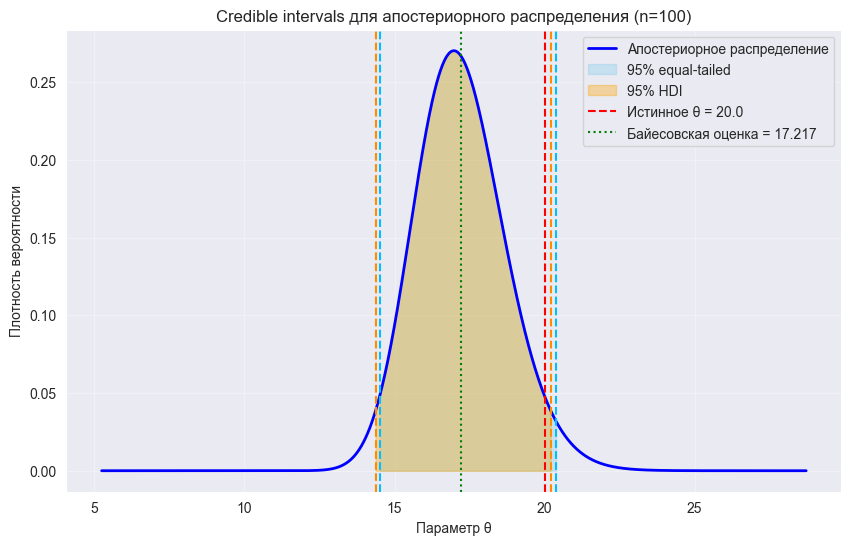

In [46]:
plot_credible_intervals(theta_grid, density, theta_true, (et_low, et_high), (hdi_low, hdi_high))

95% Equal-tailed credible interval (n=5000): [19.565, 20.676]
95% High-density credible interval (n=5000): [19.560, 20.670]


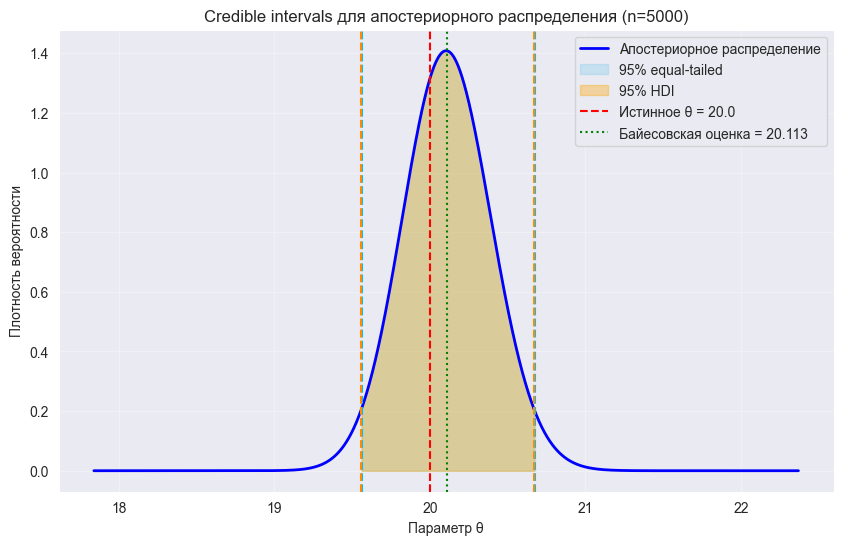

In [47]:
n = 5000
x = np.random.exponential(theta_true, n)
theta_grid, density, cdf = posterior_grid(x)

et_low, et_high = equal_tailed_interval(theta_grid, cdf)
hdi_low, hdi_high = high_density_interval(theta_grid, cdf)

print(f"95% Equal-tailed credible interval (n={n}): [{et_low:.3f}, {et_high:.3f}]")
print(f"95% High-density credible interval (n={n}): [{hdi_low:.3f}, {hdi_high:.3f}]")
plot_credible_intervals(theta_grid, density, theta_true, (et_low, et_high), (hdi_low, hdi_high))